# Tarea 3 — Pruebas de Hipótesis
## Caso de estudio: Vitalcol EPS — decisiones basadas en evidencia estadística

**Maestría en Informática — Aprendizaje Estadístico**

En este notebook se resuelven los tres ejercicios del caso Vitalcol EPS. Para cada ejercicio se desarrollan las siguientes secciones:

1. Planteamiento del problema
2. Formulación de hipótesis (H₀ y H₁)
3. Selección de la prueba
4. Análisis exploratorio
5. Ejecución de la prueba
6. Conclusión de negocio
7. Limitaciones

Nivel de significancia por defecto: **α = 0.05**


In [3]:
%pip install numpy pandas matplotlib seaborn scipy statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Imports generales (ejecutar primero)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.stats.api as sms

sns.set_theme(style="whitegrid")


---
# Ejercicio 1 — Costos operativos del programa CPV

**Nivel:** introductorio
**Prueba esperada:** comparación de medias entre dos grupos independientes.

**Contexto:** El Comité Financiero de Vitalcol está preocupado por el impacto del programa CPV en los costos
operativos: la contratación de personal adicional de triage podría estar encareciendo la atención. Se pide
determinar si el costo promedio por consulta prioritaria (en miles de pesos colombianos) difiere entre las
clínicas piloto (con CPV) y las clínicas control (sin CPV).

**Preguntas guía:**

a) ¿Existe evidencia de que el costo promedio por consulta es distinto entre clínicas piloto y control? Plantea la prueba como una comparación de dos colas.

b) Si encuentras una diferencia estadísticamente significativa, ¿es lo suficientemente grande (en pesos) como para preocupar al Comité Financiero? Argumenta tu respuesta más allá del valor p.

c) ¿Qué recomendación le darías al Comité Financiero con base en tu análisis?


### Datos del ejercicio

Ejecutar el siguiente código tal cual (no modificar).

In [2]:
np.random.seed(100)

# Costo por consulta prioritaria, en miles de pesos colombianos (COP)
costo_piloto = np.random.normal(85, 15, 140).clip(min=20)
costo_control = np.random.normal(80, 14, 130).clip(min=20)

df_costos = pd.concat([
    pd.DataFrame({'clinica': 'Piloto', 'costo_miles_cop': costo_piloto}),
    pd.DataFrame({'clinica': 'Control', 'costo_miles_cop': costo_control}),
], ignore_index=True)

df_costos.head()


,clinica,costo_miles_cop
0,Piloto,58.753518
1,Piloto,90.140206
2,Piloto,102.295537
3,Piloto,81.213459
4,Piloto,99.719812


### 1. Planteamiento del problema


> El Comité Financiero de Vitalcol sospecha que el programa CPV, al requerir personal adicional de triage, podría estar incrementando el costo por consulta. El objetivo de este análisis es determinar, con evidencia estadística, si el costo promedio por consulta prioritaria (en miles de COP) difiere entre las clínicas piloto (con CPV) y las clínicas control (sin CPV), para apoyar la decisión de si el programa debe escalarse a nivel nacional.

### 2. Formulación de hipótesis


> - H₀: μ_piloto = μ_control
> - H₁: μ_piloto ≠ μ_control
> - Tipo de prueba : dos colas
> - Justificación: Se pide evaluar si existe alguna diferencia entre las clinicas con y sin CPV, el Comité Financiero se preocuparía tanto si el CPV resulta mas caro como si resultara mas barato.


### 3. Selección de la prueba


> - La variable costo_miles_cop es de tipo numerica continua
> - Se esta comparando dos grupos, clínicas piloto (con CPV) y clínicas control (sin CPV).
> - Las muestras son independientes, son consultas provenientes de conjuntos de clínicas distintos.
> - Por el Teorema del Límite Central se espera que la prueba t sea robusta aunque los datos no sean perfectamente normales.
> - Se utilizara la prueba t de Student para dos muestras independientes, con la variante de Welch (`equal_var=False`), ya que no se puede asumir de antemano que ambos grupos tengan la misma varianza.

### 4. Análisis exploratorio



C:\Users\Jeisson\AppData\Local\Temp\ipykernel_33856\486748344.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_costos, x="clinica", y="costo_miles_cop", ax=axes[1], palette=["#1a5276", "#c0392b"])


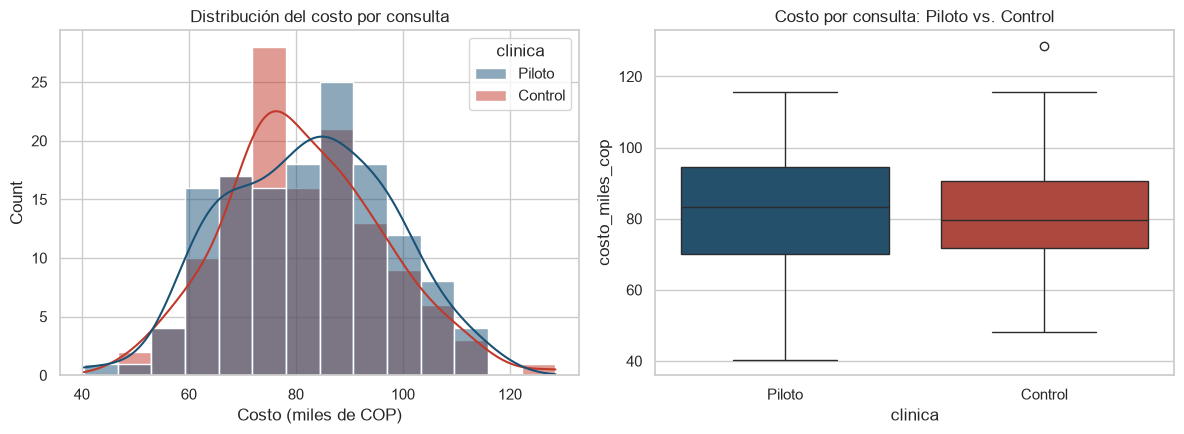

              mean        std  count
clinica                             
Control  81.621352  14.536942    130
Piloto   82.369618  15.137965    140


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histograma comparado (uno por grupo)
sns.histplot(data=df_costos, x="costo_miles_cop", hue="clinica", kde=True, ax=axes[0], palette=["#1a5276", "#c0392b"])
axes[0].set_title("Distribución del costo por consulta")
axes[0].set_xlabel("Costo (miles de COP)")

# Boxplot comparado
sns.boxplot(data=df_costos, x="clinica", y="costo_miles_cop", ax=axes[1], palette=["#1a5276", "#c0392b"])
axes[1].set_title("Costo por consulta: Piloto vs. Control")

plt.tight_layout()
plt.show()

print(df_costos.groupby("clinica")["costo_miles_cop"].agg(["mean", "std", "count"]))

> - Tanto el grupo piloto como el control muestran una distribución aproximadamente simétrica, sin sesgo  extremo evidente, similar a una campana normal. Las varianzas lucen comparables entre ambos grupos, aunque no idénticas, por lo que se mantiene  la decisión de usar la corrección de Welch (equal_var=False). Se observa además un  posible outlier en el grupo control, pero no compromete la forma general de la distribución. Dado que  n=140 y n=130 son muestras razonablemente grandes, el Teorema del Límite Central respalda el uso de la  prueba t incluso ante desviaciones menores de la normalidad perfecta.

> - Al calcular las medias exactas, la diferencia observada es de apenas ~0.75 miles de COP , mucho menor de lo que sugería la inspección visual del histograma. Las desviaciones estándar (15.14 y 14.54)  son muy similares entre los dos grupos. Esto anticipa que, aunque exista una diferencia, es probable que sea  pequeña.

### 5. Ejecución de la prueba



In [5]:

t_stat, p_value = stats.ttest_ind(
    df_costos[df_costos['clinica'] == 'Piloto']['costo_miles_cop'],
    df_costos[df_costos['clinica'] == 'Control']['costo_miles_cop'],
    equal_var=False,     # corrección de Welch
    alternative='two-sided'
)

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p:       {p_value:.4f}")

if p_value < 0.05:
    print("\nRechazamos H0: hay evidencia de que el costo promedio difiere entre clínicas piloto y control.")
else:
    print("\nNo rechazamos H0: no hay evidencia suficiente de una diferencia en el costo promedio.")

Estadístico t: 0.4143
Valor p:       0.6790

No rechazamos H0: no hay evidencia suficiente de una diferencia en el costo promedio.


### 6. Conclusión de negocio

> - El análisis no encontró evidencia de que el programa CPV haya incrementado el costo promedio por consulta prioritaria: la diferencia observada entre clínicas piloto y control (82.37 vs. 81.62 miles de COP) es estadísticamente indistinguible de cero (valor p = 0.679) y, en términos prácticos, representa menos del 1% del costo promedio, una magnitud demasiado pequeña como para preocupar al Comité Financiero incluso si hubiera resultado significativa. 
> - En consecuencia, la preocupación inicial sobre un coste mas alto causado por el personal adicional de triage no se sostiene con los datos, y el factor costo no debería ser un obstáculo para evaluar la expansión del programa a nivel nacional.


### 7. Limitaciones

> - Los datos no dicen si esta comparación se hizo en un momento específico del piloto, el costo podría cambiar con el tiempo.
> - No sabemos cómo se asignaron las clinicas a "piloto" vs "control", si no fue aleatorio podria haber otras diferencias que afecten el costo y que no estamos controlando en este caso.


### Preguntas guía — Ejercicio 1

a) ¿Existe evidencia de que el costo promedio por consulta es distinto entre clínicas piloto y control? Plantea la prueba como una comparación de dos colas.

b) Si encuentras una diferencia estadísticamente significativa, ¿es lo suficientemente grande (en pesos) como para preocupar al Comité Financiero? Argumenta tu respuesta más allá del valor p.

c) ¿Qué recomendación le darías al Comité Financiero con base en tu análisis?


> a) No, se planteó una prueba t de dos muestras independientes, de dos colas (H₀: μ_piloto = μ_control vs. H₁: μ_piloto ≠ μ_control), obteniendo un valor p = 0.679, muy por encima de α = 0.05. Por lo tanto, no hay evidencia estadística de que el costo promedio difiera entre clínicas piloto y control.
>
> b) No, la diferencia ni siquiera fue estadísticamente significativa. No obstante, la diferencia observada (82.37 vs. 81.62 miles de COP, ≈750 pesos) representa menos del 1% del costo promedio por consulta, por lo que tampoco tendría relevancia práctica aunque hubiera resultado significativa con una muestra más grande.
>
> c) Se recomienda al Comité Financiero no considerar el costo por consulta como una barrera para escalar el programa CPV, ya que no se encontró evidencia de que este incremente los costos operativos frente a las clínicas control.



---
# Ejercicio 2 — Comparación de modalidades de triage digital

**Nivel:** intermedio
**Pruebas esperadas:** comparación de medias entre 3+ grupos, y prueba de independencia entre variables categóricas.

**Contexto:** Vitalcol evalúa tres modalidades de triage digital para su siguiente fase de expansión:

- **Modalidad A:** únicamente síntomas auto-reportados por el paciente.
- **Modalidad B:** añade signos vitales capturados por un dispositivo wearable.
- **Modalidad C:** suma además un modelo de priorización basado en inteligencia artificial.

El equipo médico necesita responder dos preguntas independientes sobre estas tres modalidades.


### Datos del ejercicio

Ejecutar el siguiente código tal cual (no modificar).

In [ ]:
np.random.seed(101)

# --- Parte A: tiempo (min) hasta la primera atencion medica ---
modalidad_A = np.random.normal(24, 5, 90).clip(min=5)
modalidad_B = np.random.normal(19, 5, 90).clip(min=5)
modalidad_C = np.random.normal(15, 4, 90).clip(min=5)

df_tiempos = pd.concat([
    pd.DataFrame({'modalidad': 'A', 'tiempo_atencion_min': modalidad_A}),
    pd.DataFrame({'modalidad': 'B', 'tiempo_atencion_min': modalidad_B}),
    pd.DataFrame({'modalidad': 'C', 'tiempo_atencion_min': modalidad_C}),
], ignore_index=True)

# --- Parte B: ocurrencia de complicaciones evitables ---
modalidad = np.repeat(['A', 'B', 'C'], 90)
prob_complicacion = np.select(
    [modalidad == 'A', modalidad == 'B', modalidad == 'C'],
    [0.15, 0.09, 0.04]
)
complicacion = np.random.binomial(1, prob_complicacion)

df_modalidad = pd.DataFrame({
    'modalidad': modalidad,
    'complicacion_evitable': np.where(complicacion == 1, 'Sí', 'No')
})

df_tiempos.head()


## Parte A — Tiempo hasta la primera atención

Usa el DataFrame `df_tiempos`. ¿Existe evidencia de que el tiempo promedio hasta la primera atención difiere entre las tres modalidades?


### 1. Planteamiento del problema

> **TODO**


### 2. Formulación de hipótesis

> **TODO:**
>
> - H₀:
> - H₁:
> - Tipo de prueba:
> - Justificación:


### 3. Selección de la prueba

> **TODO**


### 4. Análisis exploratorio

In [ ]:
# TODO: análisis exploratorio Parte A


### 5. Ejecución de la prueba

In [ ]:
# TODO: ejecución de la prueba Parte A


### 6. Conclusión de negocio

> **TODO**


### 7. Limitaciones

> **TODO**


## Parte B — Complicaciones evitables

Usa el DataFrame `df_modalidad`. ¿El tipo de modalidad está asociado con la ocurrencia de complicaciones evitables?


### 1. Planteamiento del problema

> **TODO**


### 2. Formulación de hipótesis

> **TODO:**
>
> - H₀:
> - H₁:
> - Tipo de prueba:
> - Justificación:


### 3. Selección de la prueba

> **TODO**


### 4. Análisis exploratorio

In [ ]:
# TODO: análisis exploratorio Parte B (ej. tabla de contingencia, gráfico de barras)


### 5. Ejecución de la prueba

In [ ]:
# TODO: ejecución de la prueba Parte B


### 6. Conclusión de negocio

> **TODO**


### 7. Limitaciones

> **TODO**


### Preguntas guía — Ejercicio 2

a) Si la prueba de la Parte A resulta significativa, ¿qué información adicional necesitarías para saber cuál(es) modalidad(es) específica(s) difiere(n) de las demás?

b) ¿Qué implicación tiene, para la decisión de inversión de Vitalcol, encontrar evidencia en ambas partes (A y B) a favor de la Modalidad C frente a las otras dos?

c) ¿Qué otra variable te gustaría medir para descartar explicaciones alternativas antes de recomendar la Modalidad C como la única opción a escalar?

> **TODO:** responde a), b) y c) aquí.


---
# Ejercicio 3 — Evaluación del programa de capacitación en triage

**Nivel:** avanzado
**Diseño abierto:** tú decides el tipo de muestras, el supuesto de normalidad a verificar, y la prueba a aplicar.

**Contexto:** El área de Recursos Humanos de Vitalcol implementó un nuevo programa de capacitación en triage
digital para el personal de enfermería de las clínicas piloto. Antes y después de tomar la capacitación, cada
enfermero(a) presentó una evaluación de competencias (escala de 0 a 100), aplicada por la misma entidad
certificadora. Recursos Humanos quiere saber si el programa de capacitación mejoró el desempeño de su
personal, antes de decidir si lo hace obligatorio para todas las clínicas del país.


### Datos del ejercicio

Ejecutar el siguiente código tal cual (no modificar).

In [ ]:
np.random.seed(102)

n_enfermeros = 28
puntaje_antes = np.clip(np.random.normal(68, 10, n_enfermeros), 0, 100)
mejora_capacitacion = np.random.normal(9, 6, n_enfermeros)
puntaje_despues = np.clip(puntaje_antes + mejora_capacitacion, 0, 100)

df_capacitacion = pd.DataFrame({
    'enfermero_id': range(1, n_enfermeros + 1),
    'puntaje_antes': puntaje_antes,
    'puntaje_despues': puntaje_despues
})

df_capacitacion.head()


### 1. Planteamiento del problema

> **TODO**


### a) Muestras independientes o pareadas

_(Determina si las dos mediciones —antes/después— deben tratarse como muestras independientes o pareadas, y justifica tu respuesta)_

> **TODO**


### 2. Formulación de hipótesis

> **TODO:**
>
> - H₀:
> - H₁:
> - Tipo de prueba:
> - Justificación:


### b) Evaluación visual de la diferencia (después − antes)

_(Evalúa visualmente si la diferencia luce razonablemente simétrica/normal y documenta qué observas)_


In [ ]:
# TODO: calcular la diferencia (despues - antes) y graficar (histograma / Q-Q plot / boxplot)


### 3. Selección de la prueba

### c) Prueba paramétrica vs. no paramétrica

_(Con base en el punto anterior, elige y justifica si aplicarías una prueba paramétrica o no paramétrica. Ejecuta la prueba elegida)_

> **TODO:** justificación de la elección.


In [ ]:
# TODO: ejecución de la prueba elegida (paramétrica o no paramétrica)


### d) Prueba alternativa (comparación)

_(Ejecuta también la prueba que NO elegiste y compara ambos resultados: ¿cambia la conclusión de negocio según la prueba usada?)_


In [ ]:
# TODO: ejecución de la prueba alternativa


> **TODO:** comparación de resultados entre ambas pruebas.


### 4. Análisis exploratorio adicional (opcional)

In [ ]:
# TODO: análisis exploratorio adicional si aplica


### e) Conclusión de negocio / recomendación final

_(Redacta la recomendación final para Recursos Humanos: ¿debería el programa de capacitación hacerse obligatorio a nivel nacional?)_

> **TODO**


### 7. Limitaciones

> **TODO:** menciona al menos una limitación o supuesto a considerar.
